In [124]:
cems_variables = ['temp',
                  'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'prec24h',
                'dc', 'ffmc', 'dmc', 'nesterov', 'munger', 'kbdi',
                'isi', 'angstroem', 'bui', 'fwi', 'dailySeverityRating',
                'temp16',
                'dwpt16', 'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16',
                'days_since_rain', 'sum_consecutive_rainfall', 'sum_rain_last_7_days',
                'sum_snow_last_7_days', 'snow24h', 'snow24h16',
                'precipitationIndexN3', 'precipitationIndexN5', 'precipitationIndexN7'
                ]

air_variables = ['O3', 'NO2', 'PM10', 'PM25']

# Encoder
sentinel_variables = ['NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI']
landcover_variables = [
                      'foret_encoder',
                      'argile_encoder',
                      'cosia_encoder'
                        ]

cluster_encoder = ['cluster_encoder', 'id_encoder']

calendar_variables = ['month', 'dayofyear', 'dayofweek', 'isweekend', 'couvrefeux', 'confinemenent',
                    'ramadan', 'bankHolidays', 'bankHolidaysEve', 'holidays', 'holidaysBorder',
                    'calendar_mean', 'calendar_min', 'calendar_max', 'calendar_sum']

geo_variables = ['departement_encoder']
region_variables = ['region_class']

# Percentage
foret_variables = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
cosia_variables = [
    'Other',
    'Building',
    'Bare soil',
    'Water surface',
    'Conifer',
    'Deciduous',
    'Shrubland',
    'Lawn',
    'Crop'
]

osmnx_variables = ['0', '1', '2', '3', '4', '5']
dynamic_world_variables = ['water', 'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow']

# Influence 
historical_variables = ['pastinfluence']
auto_regression_variable_reg = ['J-1',
                                 #'J-2', 'J-3', 'J-4', 'J-5', 'J-6', 'J-7'
                                ]
auto_regression_variable_bin = ['B-1',
                                #'B-2', 'B-3', 'B-4', 'B-5', 'B-6', 'B-7'
                                ]

# Other
elevation_variables = ['elevation']
population_variabes = ['population']
vigicrues_variables = ['12',
                       #'16'
                      ]

nappes_variables = ['niveau_nappe_eau', 'profondeur_nappe']

# Time varying
varying_time_variables = ['temp_mean', 'dwpt_mean', 'rhum_mean', 'wdir_mean', 'wspd_mean',
                            'dc_mean', 'ffmc_mean', 'dmc_mean', 'nesterov_mean', 'munger_mean', 'kbdi_mean',
                            'isi_mean', 'angstroem_mean', 'bui_mean', 'fwi_mean', 'dailySeverityRating_mean',
                            'temp16_mean', 'dwpt16_mean', 'rhum16_mean', 'wdir16_mean', 'wspd16_mean',
                            #'air_mean',
                            #'Calendar_mean',

                            'temp_min', 'dwpt_min', 'rhum_min', 'wdir_min', 'wspd_min',
                            'dc_min', 'ffmc_min', 'dmc_min', 'nesterov_min', 'munger_min', 'kbdi_min',
                            'isi_min', 'angstroem_min', 'bui_min', 'fwi_min', 'dailySeverityRating_min',
                            'temp16_min', 'dwpt16_min', 'rhum16_min', 'wdir16_min', 'wspd16_min',
                            #'air_min',
                            #'Calendar_min',

                            'temp_max', 'dwpt_max', 'rhum_max', 'wdir_max', 'wspd_max',
                            'dc_max', 'ffmc_max', 'dmc_max', 'nesterov_max', 'munger_max', 'kbdi_max',
                            'isi_max', 'angstroem_max', 'bui_max', 'fwi_max', 'dailySeverityRating_max',
                            'temp16_max', 'dwpt16_max', 'rhum16_max', 'wdir16_max', 'wspd16_max',
                            #'air_max',
                            #'Calendar_max',

                            #'Historical_sum',
                            #'Historical_grad',
                            #'AutoRegressionBin_sum',
                            #'AutoRegressionReg_sum',
                            #'AutoRegressionReg_grad'
                            ]

varying_time_variables_name = []

In [125]:
import pickle
from pathlib import Path
import datetime as dt

def find_dates_between(start, end):
    start_date = dt.datetime.strptime(start, '%Y-%m-%d').date()
    end_date = dt.datetime.strptime(end, '%Y-%m-%d').date()

    delta = dt.timedelta(days=1)
    date = start_date
    res = []
    while date < end_date:
            res.append(date.strftime("%Y-%m-%d"))
            date += delta
    return res

def read_object(filename: str, path : Path):
    if not (path / filename).is_file():
        return None
    return pickle.load(open(path / filename, 'rb'))

allDates = find_dates_between('2017-06-12', '2024-06-29')

In [126]:
import numpy as np

def load_features(variables, sdate_year, edate_year, dir_data):

    vec_x = []
    
    for var in variables:
        if var in cems_variables:
            values = read_object(f'{var}raw.pkl', dir_data)
            assert values is not None
            values = values[:, :, allDates.index(sdate_year):allDates.index(edate_year)]
            values = np.mean(values, axis=2)
            vec_x.append(values)

        elif var == 'population' or var == 'elevation':
            values = read_object(f'{var}.pkl', dir_data)
            assert values is not None
            values = values.reshape((values.shape[0], values.shape[1]))
            vec_x.append(values)

        elif var == 'foret':
            values = read_object(f'{var}.pkl', dir_data)
            assert values is not None
            for i, var2 in enumerate(foret_variables):
                values2 = values[i]
                vec_x.append(values2)

        elif var == 'cosia':
            values = read_object(f'{var}.pkl', dir_data)
            assert values is not None
            for i, var2 in enumerate(cosia_variables):
                values2 = values[i]
                vec_x.append(values2)

        elif var == 'air':
            assert values is not None
            for i, var2 in enumerate(air_variables):
                values = read_object(f'{var2}raw.pkl', dir_data)
                assert values is not None
                values = values[:, :, allDates.index(sdate_year):allDates.index(edate_year)]
                values = np.mean(values, axis=2)
                vec_x.append(values)

        elif var == 'sentinel':
            values = read_object(f'{var}.pkl', dir_data)
            assert values is not None
            for i, var2 in enumerate(sentinel_variables):
                values2 = np.mean(values[i, :, :, allDates.index(sdate_year):allDates.index(edate_year)], axis=2)
                vec_x.append(values2)

        elif var == 'vigicrues':
            assert values is not None
            for i, var2 in enumerate(vigicrues_variables):
                values = read_object(f'vigicrues{var2}.pkl', dir_data)
                assert values is not None
                values = values[:, :, allDates.index(sdate_year):allDates.index(edate_year)]
                values = np.mean(values, axis=2)
                vec_x.append(values)

        elif var == 'nappes':
            for i, var2 in enumerate(nappes_variables):
                values = read_object(f'{var2}.pkl', dir_data)
                assert values is not None
                values = values[:, :, allDates.index(sdate_year):allDates.index(edate_year)]
                values = np.mean(values, axis=2)
                vec_x.append(values)

        elif var == 'osmnx':
            values = read_object(f'osmnx.pkl', dir_data)
            assert values is not None
            for i, var2 in enumerate(osmnx_variables):
                values2 = values[i]
                vec_x.append(values2)

        elif var == 'dynamic_world':
            values = read_object(f'{var}.pkl', dir_data)
            assert values is not None
            for i, var2 in enumerate(dynamic_world_variables):
                values2 = np.mean(values[i, :, :, allDates.index(sdate_year):allDates.index(edate_year)], axis=2)
                vec_x.append(values2)
        else:
            raise ValueError(f'Unknow variable {var}')
        
    return np.asarray(vec_x)

In [133]:
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations
from scipy.spatial.distance import braycurtis

def compute_bray_curtis_similarity_with_clustering_and_groups(region_image, feature_array, threshold=0.5):
    """
    Calcule l'indice de Bray-Curtis entre chaque paire de zones identifiées dans une image régionale,
    effectue un clustering hiérarchique et retourne les groupes selon un seuil donné.

    Parameters:
    - region_image (2D np.array): Image avec identifiants de zones (pixels 0 ou nan ignorés).
    - feature_array (3D np.array): Tableau (H, W, F) avec les features spatiales par pixel.
    - threshold (float): Seuil de distance pour découper l'arbre de clustering (entre 0 et 1).

    Returns:
    - DataFrame avec les indices de similarité Bray-Curtis entre chaque paire d'IDs.
    - DataFrame avec l'affectation de chaque zone à un cluster.
    - Affichage du dendrogramme.
    """
    assert region_image.shape == feature_array.shape[:2], "Dimension mismatch"

    valid_mask = (~np.isnan(region_image)) & (region_image != 0)
    region_ids = np.unique(region_image[valid_mask])

    region_features = {}
    for region_id in region_ids:
        mask = region_image == region_id
        masked_features = feature_array[mask]
        mean_features = np.nanmean(masked_features, axis=0)
        region_features[region_id] = mean_features

    feature_matrix = np.array([region_features[region_id] for region_id in region_ids])

    # Clustering hiérarchique sur les distances de Bray-Curtis
    Z = linkage(feature_matrix, method='average', metric='braycurtis')

    # Découpe des clusters selon le seuil de dissimilarité
    cluster_labels = fcluster(Z, t=threshold, criterion='distance')
    cluster_df = pd.DataFrame({'Zone_ID': region_ids, 'Cluster': cluster_labels})
    #tools.display_dataframe_to_user(name="Cluster Assignments", dataframe=cluster_df)

    # Affichage du dendrogramme
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=region_ids.astype(int), color_threshold=threshold)
    plt.title(f'Clustering hiérarchique des zones (seuil={threshold})')
    plt.xlabel('Zone')
    plt.ylabel('Distance (Bray-Curtis)')
    plt.tight_layout()
    plt.show()

    # Calcul des similarités Bray-Curtis
    results = []
    for (i, j) in combinations(range(len(region_ids)), 2):
        id1, id2 = region_ids[i], region_ids[j]
        vec1 = feature_matrix[i]
        vec2 = feature_matrix[j]
        distance = braycurtis(vec1, vec2)
        similarity = 1 - distance
        results.append({'Zone_1': id1, 'Zone_2': id2, 'Bray_Curtis_Similarity': similarity})

    df = pd.DataFrame(results)
    #tools.display_dataframe_to_user(name="Bray-Curtis Similarity Between Zones", dataframe=df)

    res_merge = np.full(region_image.shape, fill_value=np.nan)
    res_merge[region_image == 0] = 0.0
    for region_id in region_ids:
        res_merge[region_image == region_id] = cluster_df[cluster_df['Zone_ID'] == region_id]['Cluster'].values[0]

    return df, cluster_df, res_merge

In [212]:
departement = 'departement-01-ain'

variables = ['fwi', 'foret']

root_target = Path('/home/caron/Bureau/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/features_geometry')
root_features = Path(f'/media/caron/X9 Pro/travaille/Thèse/csv/{departement}/raster/2x2')

regions = read_object(f'watershed_{departement}.pkl', root_target)
features = load_features(variables, '2022-06-01', '2022-07-01', root_features)

features = np.moveaxis(features, 0, 2)
features.shape

(45, 51, 23)

In [207]:
regions.shape, np.unique(features)

((45, 51),
 array([ 0.        , 15.89294734, 16.72608422, ..., 24.66415465,
        24.69854002,         nan]))

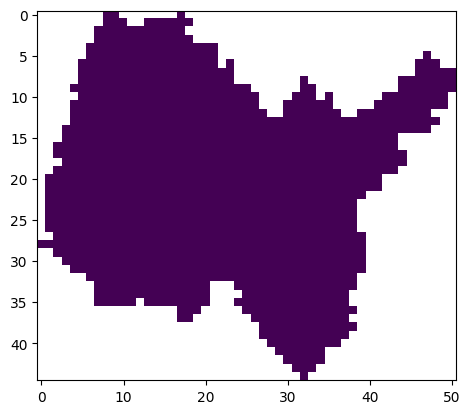

In [213]:
plt.imshow(features[:, :, 4])

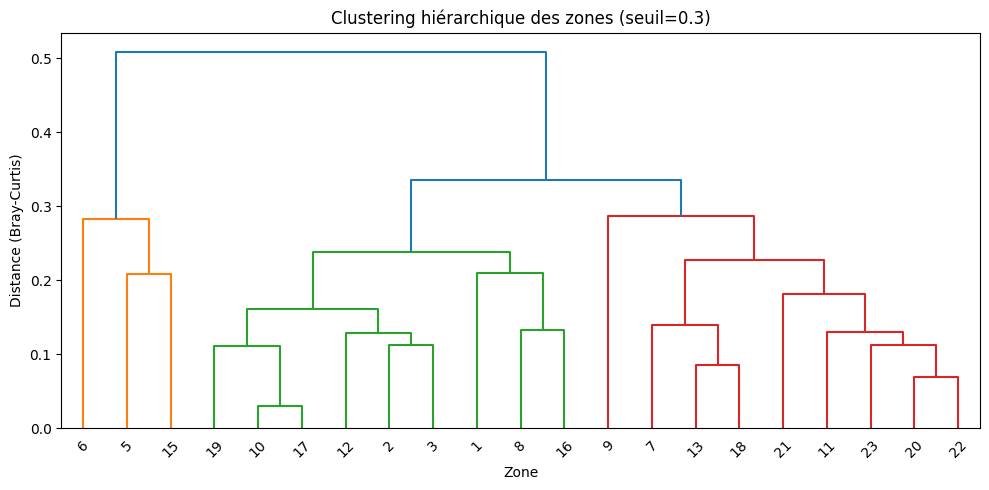

In [217]:
df, cluster_df, res = compute_bray_curtis_similarity_with_clustering_and_groups(regions, features, threshold=0.3)

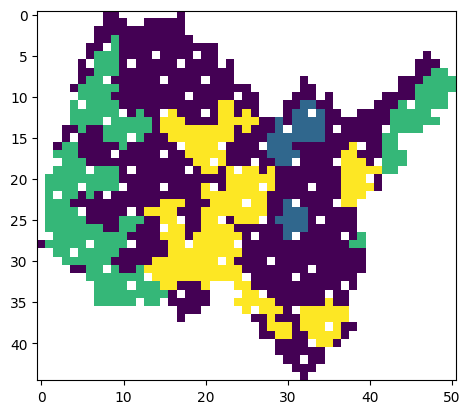

In [218]:
plt.imshow(res)